# AR Model Notebook

1. **Setup** - Imports and helper functions
2. **Simulation 1** - Generating synthetic AR(1) data and checking stationarity
3. **Model 1: AR(1) on Synthetic Data** - Basically taken line-for-line from the Stan documentation
4. **Simulation 2** - Generating 5 series of AR(1) data that is generated from a CAR model as described in the Stan documentation.
4. **Model 2: Hierarchical AR (ICAR Prior) on Synthetic Data** - Fitting `ar_1_hierarchical.stan`
5. **Model 3: AR(1) on CTA Red Line Data** - Fitting `ar_1_cta.stan` to real weekly ridership

---
## 1. Setup

Imports and CmdStan path configuration.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from cmdstanpy import CmdStanModel, set_cmdstan_path
set_cmdstan_path("/deac/sta/classes/sta720/software/cmdstan/2.37.0")

In [3]:
def sim_ar_model(alpha, beta, sigma, T, initial=0, seed=None):
    np.random.seed(seed)
    assert T >= 1

    Y = np.zeros(T)
    epsilon = np.random.normal(0, sigma, size=T)

    Y[0] = initial

    for t in range(1, T):
        Y[t] = alpha + beta * Y[t - 1] + epsilon[t]
    return Y

## 2. Simulate AR(1) Data

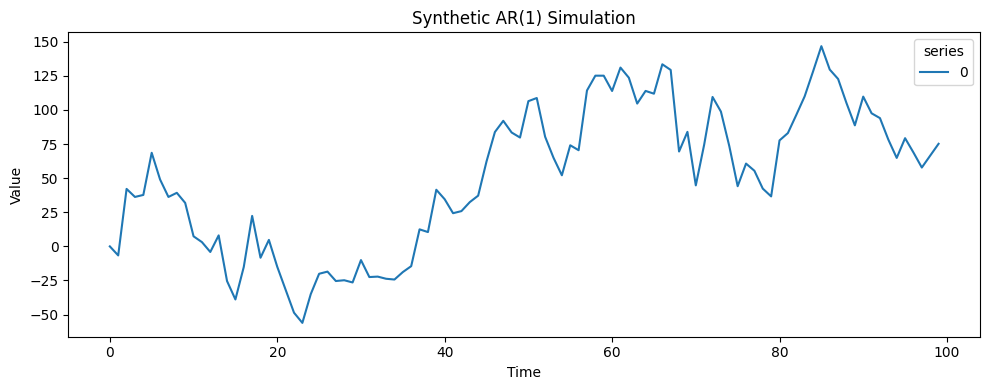

In [8]:
T = 100
alpha = 0
beta= 0.98
sigma = 20

y = sim_ar_model(alpha = alpha, beta = beta, sigma = 20, T = T, seed = 5)

df_sim = pd.DataFrame(y)
df_sim["t"] = range(T)
df_sim_long = df_sim.melt(id_vars="t", var_name="series", value_name="value")

plt.figure(figsize=(10, 4))
sns.lineplot(data=df_sim_long, x="t", y="value", hue="series")
plt.title("Synthetic AR(1) Simulation")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 3. Model 1: AR(1) on Simulated Data

In [9]:
stan_data_ar1_sim = {
    "T": T,
    "y": y
}

ar_mod = CmdStanModel(stan_file="ar_1.stan")
ar_mod_post = ar_mod.sample(data=stan_data_ar1_sim)
print(ar_mod_post.diagnose())

22:15:20 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

22:15:20 - cmdstanpy - INFO - CmdStan done processing.



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### 3.1 Parameter Recovery

In [10]:
ar_mod_params = ar_mod_post.stan_variables()

print("True alpha:", alpha)
print("Estimated alpha:", ar_mod_params["alpha"].mean(axis=0))
print()
print("True beta:", beta)
print("Estimated beta:", ar_mod_params["beta"].mean(axis=0))
print()
print("True sigma:", sigma)
print("Estimated sigma:", ar_mod_params["sigma"].mean(axis=0))

True alpha: 0
Estimated alpha: 4.271614593160495

True beta: 0.98
Estimated beta: 0.9301393122675

True sigma: 20
Estimated sigma: 18.94218422775


In [17]:
print(ar_mod_post.summary())

            Mean      MCSE    StdDev       MAD          5%         50%  \
lp__  -331.60400  0.028463  1.273420  1.037240 -334.066000 -331.285000   
alpha    1.91480  0.036918  1.997090  1.999990   -1.288680    1.901320   
beta     0.97951  0.000456  0.024198  0.023889    0.939005    0.979751   
sigma   17.99950  0.026867  1.367720  1.330240   15.903700   17.903100   

             95%  ESS_bulk  ESS_tail  ESS_bulk/s    R_hat  
lp__  -330.22200   1912.10   2790.88     9019.35  1.00192  
alpha    5.20791   2936.95   2968.19    13853.50  1.00129  
beta     1.01880   2827.60   2860.88    13337.70  1.00168  
sigma   20.27880   2664.83   2513.38    12569.90  1.00165  


## 4. Simulate Network AR(1) Data

In [4]:
def sim_ar_net_model(gamma, delta, c, beta, W, tau, alpha, T, initial=None, seed=None):
    np.random.seed(seed)
    K = len(c)
    assert W.shape == (K, K)
    assert T >= 1

    # precision matrix (Q)
    D = np.diag(W.sum(axis=1))
    Q = tau * (D - alpha * W)
    Sigma = np.linalg.inv(Q)

    # Simulate
    Y = np.zeros((T, K))
    if initial is not None:
        Y[0] = initial

    epsilon = np.random.multivariate_normal(np.zeros(K), Sigma, size=T)

    for t in range(1, T):
        Y[t] = gamma + delta * Y[t - 1] + c + beta * Y[t - 1] + epsilon[t]

    return Y, Sigma

In [5]:
K = 5
W = np.zeros((K, K))
for i in range(K - 1):
    W[i, i + 1] = 1
    W[i + 1, i] = 1

print("Adjacency matrix W:")
print(W)

# Simulation parameters
c_net = np.array([1.0, 1.5, 1.7, 1.5, 1.0])       # all node-level intercepts
beta_net = np.array([0.32, 0.3, 0.5, 0.67, 0.7])   # all node-level coefficients
gamma_net = c_net.mean()                             # population intercept (hierarchical mean)
delta_net = beta_net.mean()                          # population AR coefficient (hierarchical mean)
alpha_net = 0.8   # spatial correlation (0 < alpha < 1)
tau_net = 1.0
T_net = 200

Y_net, Sigma_net = sim_ar_net_model(
    delta=0, gamma=0,
    c=c_net, beta=beta_net, W=W,
    tau=tau_net, alpha=alpha_net, T=T_net, seed=42
)

print(f"\nSimulated data shape: {Y_net.shape}")
print(f"\nPopulation intercept (gamma): {gamma_net}")
print(f"Population coefficient (delta): {delta_net}")
print(f"\nInnovation covariance Sigma:")
print(np.round(Sigma_net, 3))

Adjacency matrix W:
[[0. 1. 0. 0. 0.]
 [1. 0. 1. 0. 0.]
 [0. 1. 0. 1. 0.]
 [0. 0. 1. 0. 1.]
 [0. 0. 0. 1. 0.]]

Simulated data shape: (200, 5)

Population intercept (gamma): 1.34
Population coefficient (delta): 0.49800000000000005

Innovation covariance Sigma:
[[1.68  0.85  0.444 0.261 0.209]
 [0.85  1.062 0.556 0.327 0.261]
 [0.444 0.556 0.944 0.556 0.444]
 [0.261 0.327 0.556 1.062 0.85 ]
 [0.209 0.261 0.444 0.85  1.68 ]]


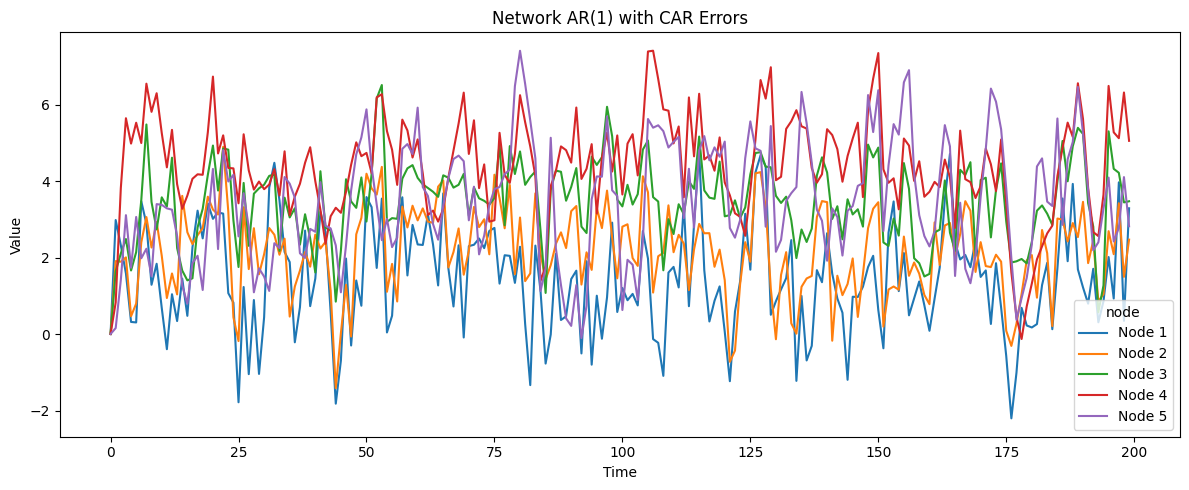

In [6]:
# Plot all 5 nodes
df_net = pd.DataFrame(Y_net, columns=[f"Node {i+1}" for i in range(K)])
df_net["t"] = range(T_net)
df_net_long = df_net.melt(id_vars="t", var_name="node", value_name="value")

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_net_long, x="t", y="value", hue="node")
plt.title("Network AR(1) with CAR Errors")
plt.xlabel("Time")
plt.ylabel("Value")
plt.tight_layout()
plt.show()

## 4. Model 2: AR(1) on Simulated Network Data

In [26]:
stan_data_hier = {
    "T": T_net,
    "K": len(c_net),
    "Y": Y_net
}

ar_mod_hier = CmdStanModel(stan_file="ar_1_hierarchical.stan")
ar_mod_hier_post = ar_mod_hier.sample(data=stan_data_hier)
print(ar_mod_hier_post.diagnose())

23:12:01 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

23:12:11 - cmdstanpy - INFO - CmdStan done processing.
23:12:11 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical.stan', line 39, column 6 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical.stan', line 39, column 6 to column 61)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
	Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
Exception: gamma_lpdf: Random variable is inf, but must be positive finite! (in 'ar_1_hierarchical.stan', line 24, column 2 to column 28)
Exception: normal_lpdf: Scale parameter is 0, but must be positi


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
2 of 4000 (0.05%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



In [27]:
ar_mod_hier_params = ar_mod_hier_post.stan_variables()

print("=== Population Level ===")
print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_hier_params["gamma"].mean(axis=0))
print()
print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_hier_params["delta"].mean(axis=0))
print()
print("=== Node Level ===")
print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_hier_params["c"].mean(axis=0))
print()
print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_hier_params["beta"].mean(axis=0))
print()
print("=== Innovation SD ===")
print("True sigma (diag of Sigma):", np.sqrt(np.diag(Sigma_net)))
print("Estimated sigma:", ar_mod_hier_params["sigma"].mean(axis=0))

=== Population Level ===
True gamma (pop intercept): 1.34
Estimated gamma: 1.283297983647975

True delta (pop coefficient): 0.49800000000000005
Estimated delta: 0.5297288585575

=== Node Level ===
True c (node intercepts): [1.  1.5 1.7 1.5 1. ]
Estimated c: [0.9600678  1.28250322 1.7747554  1.64570433 1.31867774]

True beta (node coefficients): [0.32 0.3  0.5  0.67 0.7 ]
Estimated beta: [0.35144853 0.40699132 0.48801794 0.63081187 0.62216676]

=== Innovation SD ===
True sigma (diag of Sigma): [1.29604728 1.03057824 0.97182532 1.03057824 1.29604728]
Estimated sigma: [1.28407372 1.02828715 0.94908938 0.99070816 1.18712601]


In [28]:
print(ar_mod_hier_post.summary())

                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__        -570.539000  0.086088  3.509610  3.404790 -576.856000 -570.143000   
gamma          1.283300  0.006804  0.331532  0.251048    0.694794    1.312470   
delta          0.529729  0.001790  0.100610  0.086836    0.372160    0.523270   
c[1]           0.960068  0.002395  0.131283  0.130813    0.746284    0.959381   
c[2]           1.282500  0.002775  0.151331  0.151537    1.037740    1.281710   
c[3]           1.774760  0.004487  0.213551  0.217142    1.418910    1.777510   
c[4]           1.645700  0.004530  0.225634  0.225615    1.274330    1.642800   
c[5]           1.318680  0.003259  0.181215  0.181531    1.020640    1.318530   
beta[1]        0.351449  0.001219  0.065071  0.062862    0.244217    0.350647   
beta[2]        0.406991  0.001106  0.062995  0.060889    0.301535    0.408121   
beta[3]        0.488018  0.001216  0.059117  0.059605    0.392102    0.486708   
beta[4]        0.630812  0.0

## 5. Model 3: Hierarchical AR(1) with ICAR Prior on Simulated Network Data

In [10]:
node1 = []
node2 = []
for i in range(K):
    for j in range(i + 1, K):
        if W[i, j] == 1:
            node1.append(i + 1)
            node2.append(j + 1)

N_edges = len(node1)
print(f"Number of edges: {N_edges}")
print(f"Edge list: {list(zip(node1, node2))}")

stan_data_icar = {
    "T": T_net,
    "K": K,
    "Y": Y_net,
    "N_edges": N_edges,
    "node1": node1,
    "node2": node2
}

print(node1)
print(node2)

Number of edges: 4
Edge list: [(1, 2), (2, 3), (3, 4), (4, 5)]
[1, 2, 3, 4]
[2, 3, 4, 5]


In [30]:
ar_mod_icar = CmdStanModel(stan_file="ar_1_hierarchical_icar.stan")
ar_mod_icar_post = ar_mod_icar.sample(data=stan_data_icar)
print(ar_mod_icar_post.diagnose())

23:12:56 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

23:14:34 - cmdstanpy - INFO - CmdStan done processing.
23:14:34 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is -inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parameter[1] is inf, but must be finite! (in 'ar_1_hierarchical_icar.stan', line 45, column 4 to column 65)
	Exception: normal_lpdf: Location parame


Checking sampler transitions treedepth.
3140 of 4000 (78.50%) transitions hit the maximum treedepth limit of 10, or 2^10 leapfrog steps.
Trajectories that are prematurely terminated due to this limit will result in slow exploration.
For optimal performance, increase this limit.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete.



### 5.1 Parameter Recovery

In [31]:
ar_mod_icar_params = ar_mod_icar_post.stan_variables()

print("=== Population Level ===")
print("True gamma (pop intercept):", gamma_net)
print("Estimated gamma:", ar_mod_icar_params["gamma"].mean(axis=0))
print()
print("True delta (pop coefficient):", delta_net)
print("Estimated delta:", ar_mod_icar_params["delta"].mean(axis=0))
print()
print("=== Node Level ===")
print("True c (node intercepts):", c_net)
print("Estimated c:", ar_mod_icar_params["c"].mean(axis=0))
print()
print("True beta (node coefficients):", beta_net)
print("Estimated beta:", ar_mod_icar_params["beta"].mean(axis=0))
print()
print("=== Innovation SD ===")
print("True sigma (diag of Sigma):", np.sqrt(np.diag(Sigma_net)))
print("Estimated sigma:", ar_mod_icar_params["sigma"].mean(axis=0))

=== Population Level ===
True gamma (pop intercept): 1.34
Estimated gamma: 1.3309854135282502

True delta (pop coefficient): 0.49800000000000005
Estimated delta: 0.4984955516675

=== Node Level ===
True c (node intercepts): [1.  1.5 1.7 1.5 1. ]
Estimated c: [0.98066109 1.2967786  1.73212236 1.66677345 1.30787949]

True beta (node coefficients): [0.32 0.3  0.5  0.67 0.7 ]
Estimated beta: [0.34126919 0.40084569 0.49871679 0.62524997 0.62639199]

=== Innovation SD ===
True sigma (diag of Sigma): [1.29604728 1.03057824 0.97182532 1.03057824 1.29604728]
Estimated sigma: [1.30698166 1.02116045 0.9357322  0.98063139 1.19483964]


In [32]:
print(ar_mod_icar_post.summary())

                   Mean      MCSE    StdDev       MAD          5%         50%  \
lp__        -584.066000  0.112066  3.642400  3.613520 -590.570000 -583.703000   
gamma          1.330990  0.006130  0.241473  0.196841    0.944358    1.343260   
c_zero[1]     -0.940681  0.015459  0.661123  0.656614   -2.072470   -0.907740   
c_zero[2]     -0.119889  0.011750  0.545056  0.535209   -1.029500   -0.114413   
c_zero[3]      0.963831  0.011982  0.623352  0.608666    0.016921    0.916635   
c_zero[4]      0.766548  0.012198  0.633693  0.617292   -0.254633    0.763139   
c_zero[5]     -0.100122  0.012223  0.600619  0.589658   -1.127050   -0.092689   
sigma_c        0.462166  0.006335  0.245383  0.184935    0.183679    0.403717   
delta          0.498496  0.000351  0.027030  0.027349    0.454224    0.498842   
phi_zero[1]   -1.314720  0.015697  0.630510  0.593711   -2.474920   -1.228660   
phi_zero[2]   -0.823922  0.011292  0.472184  0.447281   -1.699790   -0.761425   
phi_zero[3]   -0.003350  0.0